===== DATASET 1: SYNTHETIC DATA =====

Lowest SSE (Inertia): 72.55689689365892
Final Centroid Locations:
 [[ 1.19933242  0.13126124]
 [-0.25738366  1.05892303]
 [-0.92404827 -1.18822514]]
Number of Iterations to Converge: 9
Predicted Labels for First 10 Points: [0 1 2 2 2 2 1 2 0 2]


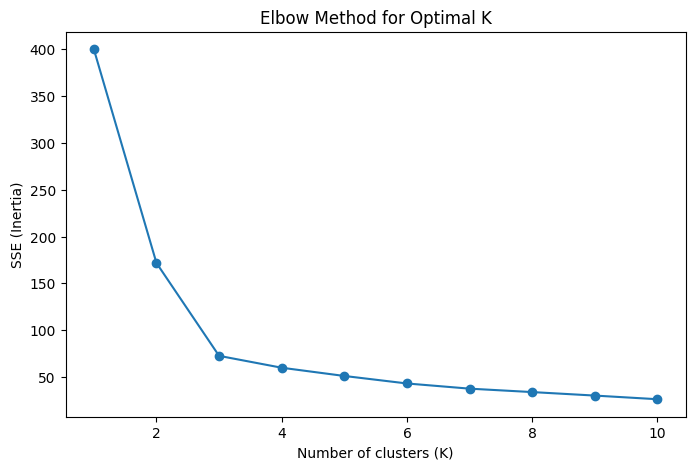

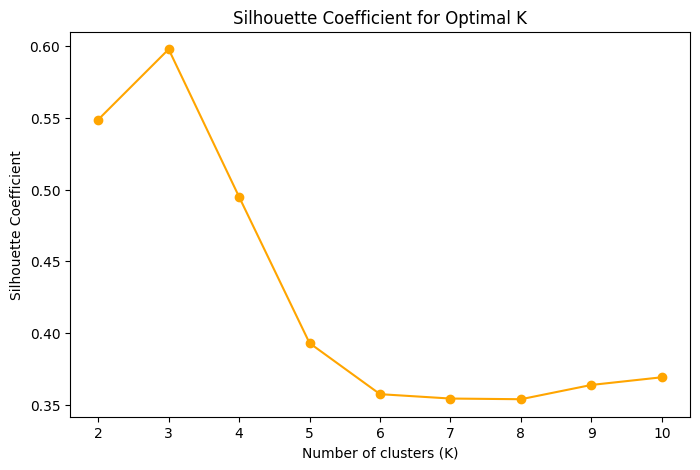


Maximum Silhouette Coefficient: 0.5979
Respective Number of Clusters (K): 3

Davies-Bouldin Score: 0.5713


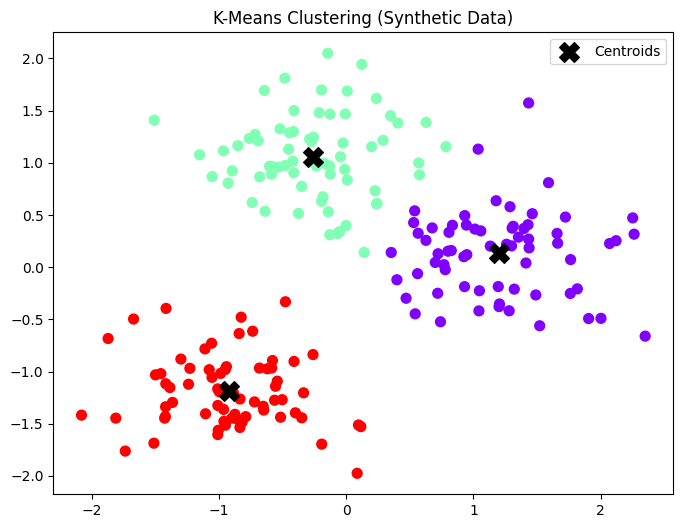

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

# DATASET 1: SYNTHETIC DATA
print("===== DATASET 1: SYNTHETIC DATA =====")

# 1. Generate synthetic dataset
X, y_true = make_blobs(n_samples=200, centers=3, cluster_std=2.7, random_state=42)

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Perform K-means clustering
kmeans = KMeans(
    n_clusters=3,        # number of clusters (K)
    init='random',       # random initialization
    n_init=10,           # 10 variations of initial means
    max_iter=300,        # 300 iterations
    random_state=42
)
kmeans.fit(X_scaled)

# 3. Output key results
print("\nLowest SSE (Inertia):", kmeans.inertia_)
print("Final Centroid Locations:\n", kmeans.cluster_centers_)
print("Number of Iterations to Converge:", kmeans.n_iter_)
print("Predicted Labels for First 10 Points:", kmeans.labels_[:10])

# 4. Elbow Method (Optimal K)
sse = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.show()

# 5. Silhouette Coefficient Method
silhouette_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Coefficient for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Coefficient')
plt.show()

# 6. Print Max Silhouette Score and Respective K
max_silhouette = max(silhouette_scores)
best_k = silhouette_scores.index(max_silhouette) + 2
print("\nMaximum Silhouette Coefficient:", round(max_silhouette, 4))
print("Respective Number of Clusters (K):", best_k)

# 7. Davies-Bouldin Score
db_score = davies_bouldin_score(X_scaled, kmeans.labels_)
print("\nDavies-Bouldin Score:", round(db_score, 4))

# Visualize Clusters
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, cmap='rainbow', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color='black', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering (Synthetic Data)")
plt.legend()
plt.show()


===== DATASET 2: CUSTOM DATA =====
First 5 rows:
    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Selected Numeric Columns:
 ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']

Lowest SSE (Inertia): 4201.4938082759645
F

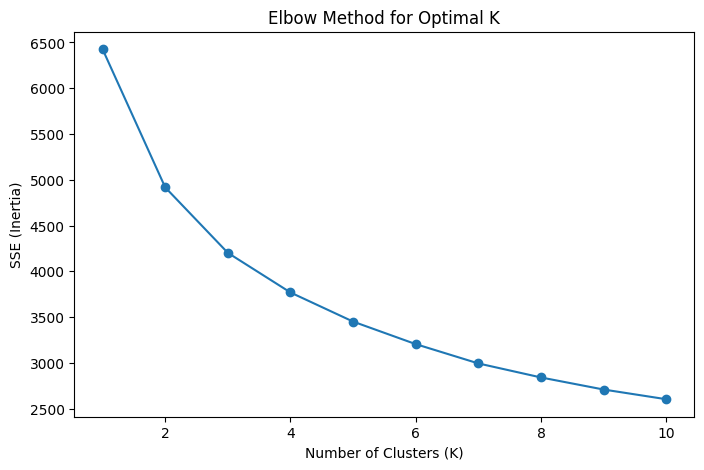

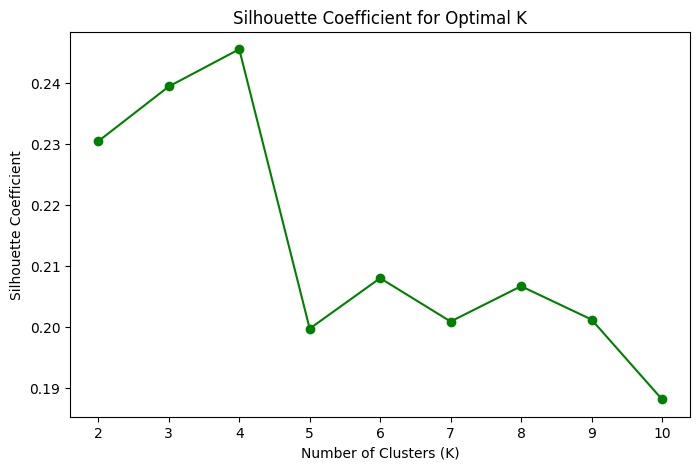


Maximum Silhouette Coefficient: 0.2455
Respective Number of Clusters (K): 4

Davies-Bouldin Score: 1.6947


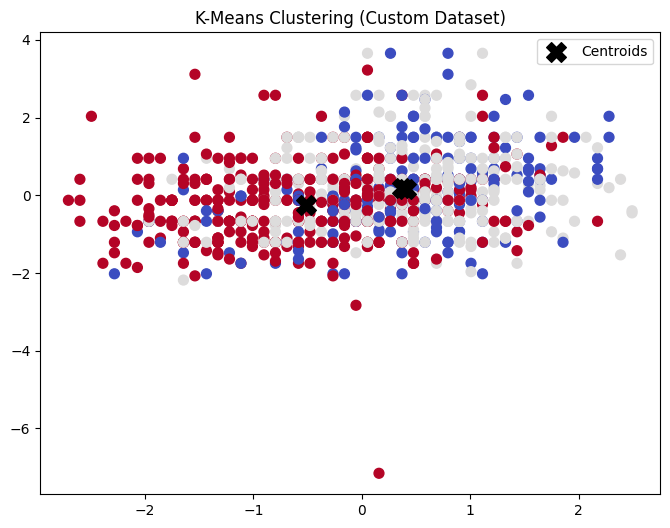

In [ ]:
print("\n===== DATASET 2: CUSTOM DATA =====")

# 🔹 STEP 1: Read your dataset
df = pd.read_csv("/content/heart (1).csv")
print("First 5 rows:\n", df.head())

# 🔹 STEP 2: Select numeric columns only (for KMeans)
numeric_df = df.select_dtypes(include=['int64', 'float64'])
print("\nSelected Numeric Columns:\n", numeric_df.columns.tolist())

# 🔹 STEP 3: Handle missing values (optional)
numeric_df.fillna(numeric_df.mean(), inplace=True)

# 🔹 STEP 4: Normalize / Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

# 🔹 STEP 5: Run K-Means clustering
kmeans = KMeans(n_clusters=3, init='random', n_init=10, max_iter=300, random_state=42)
kmeans.fit(X_scaled)

print("\nLowest SSE (Inertia):", kmeans.inertia_)
print("Final Centroid Locations:\n", kmeans.cluster_centers_)
print("Number of Iterations to Converge:", kmeans.n_iter_)
print("Predicted Labels for First 10 Points:", kmeans.labels_[:10])

# 🔹 STEP 6: Elbow Method
sse = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.show()

# 🔹 STEP 7: Silhouette Coefficients
silhouette_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.title('Silhouette Coefficient for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Coefficient')
plt.show()

max_silhouette = max(silhouette_scores)
best_k = silhouette_scores.index(max_silhouette) + 2
print("\nMaximum Silhouette Coefficient:", round(max_silhouette, 4))
print("Respective Number of Clusters (K):", best_k)

# 🔹 STEP 8: Davies-Bouldin Score
db_score = davies_bouldin_score(X_scaled, kmeans.labels_)
print("\nDavies-Bouldin Score:", round(db_score, 4))

# 🔹 STEP 9: Visualization (using first 2 numeric features)
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, cmap='coolwarm', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color='black', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering (Custom Dataset)")
plt.legend()
plt.show()